# Randomness, Random Walks, and Monte Carlo Methods

In physics, we often encounter processes which are inherently random (e.g. radioactive decay), or which lend themselves to modeling as a random process (e.g. Brownian motion).  We can analyze such processes, making use of so-called "random number generators."

## Random number generators

The term "random number generator" is a bit misleading.  They are in fact completely deterministic, but produce a sequence of numbers which have very little correlation to one another.  

A well-known example is the linear congruential random number generator.  The basis of this generator is the equation $$x^{\prime} = (ax+c) \mathrm{~mod~}m,\tag{1}$$ where $a$, $c$, and $m$ are integer constants.  Given some input integer $x$, this formula calculates a new integer $x^{\prime}$.  Plugging this integer into the equation (as $x$) will result in yet another integer.  If we repeat this process many times, the sequence of integers that results is pseudorandom.

Here is an implementation of the linear congruential random number generator:

Text(0, 0.5, 'Random Number')

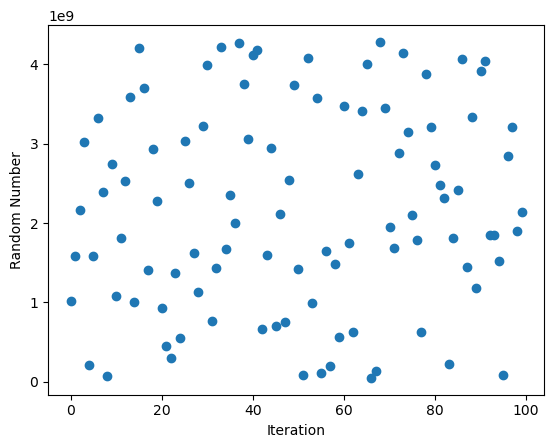

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#parameters of the generator - these have been chosen carefully to yield satisfactory performance
a = 1664525
c = 1013904223
m = 4294967296

N = 100 #how many numbers to generate
x = 1 #starting value

results = np.empty(N)

for i in range(N):
    x = (a*x+c)%m
    results[i] = x

plt.figure()
plt.plot(results,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

As can be seen from this plot, the resulting random numbers are (largely) uncorrelated.  The numbers are always positive, and because they are calculated modulo $m$, they can never be larger than this value ($4.29\times10^9$).  If we want random numbers within some alternate range, we can obtain them with minimal effort.  For example, if we need random numbers between 0 and 1, we could simply divide each of the above random numbers by $m$.

Text(0, 0.5, 'Random Number')

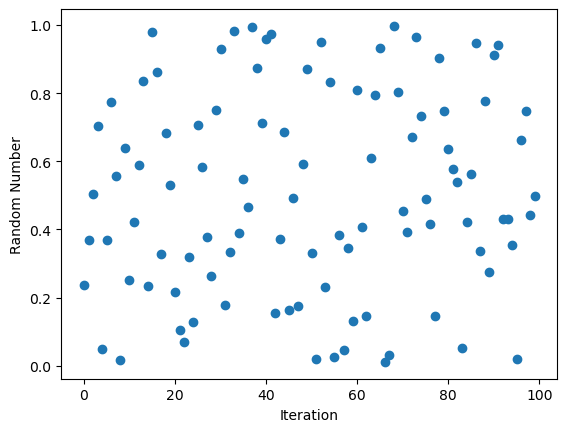

In [3]:
x = 1 #starting value

results = np.empty(N)

for i in range(N):
    x = (a*x+c)%m
    results[i] = x

plt.figure()
plt.plot(results/m,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

### Built-in random number generators

Python includes several varieties of random number generators.  While more sophisticated than the linear congruential random number generator above, they are also merely pseudorandom.

Documentation: https://docs.python.org/3/library/random.html

To generate a single random number number with a uniform probability density, use the `random()` function, which utilizes a "Mersenne twister" (a generalized feedback shift-register).

In [4]:
from random import random

for i in range(5): print(random())

0.0732813692595582
0.40979515991562354
0.43589292168391314
0.40128446510876314
0.11488127148383798


Executing the above cell multiple times results in a different sequence of random numbers each time.  Contrast that with the behavior of the following cell.

In [5]:
from random import seed

seed(42)

for i in range(5): print(random())

0.6394267984578837
0.025010755222666936
0.27502931836911926
0.22321073814882275
0.7364712141640124


Here, we get the same sequence of random numbers each time we execute the cell.  This is because the starting point of the sequence is determined by a "seed."  Once the starting point has been determined, the sequence is fully determined.  By resetting the seed before each call to `random()`, we reset the starting point and get the same sequence each time.  

For the linear congruential random number generator above, the initial value of $x$ serves as the seed.  For the built-in generator, we set the seed with the `seed()` function.

In general, if a seed is not specified, the current time is used.  Alternatively, we can specify a particular seed, which ensures that we obtain the same sequence of random numbers each time we execute our code, which makes the output repeatable (which is generally highly desirable).

The `random()` function produces random numers according to a uniform probability density in the range [0,1).  To obtain random numbers in a different interval, use the `uniform()` function with the interval specified as arguments.

Text(0, 0.5, 'Random Number')

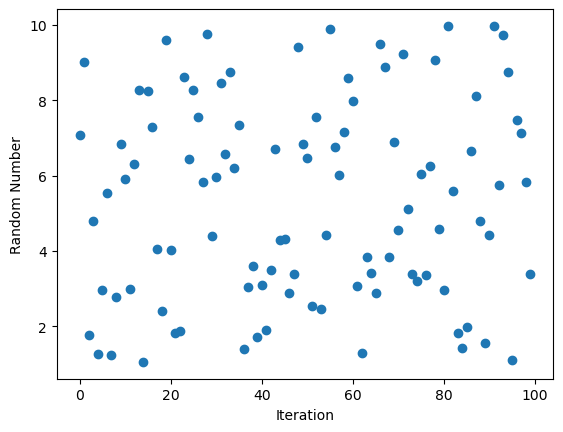

In [6]:
from random import uniform

results = np.empty(N)

for i in range(N):
    results[i] = uniform(1, 10) # random numbers within [1,10)

plt.figure()
plt.plot(results,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

To obtain random *integers* from the built-in generator, use the `randrange()` function.

Text(0, 0.5, 'Random Number')

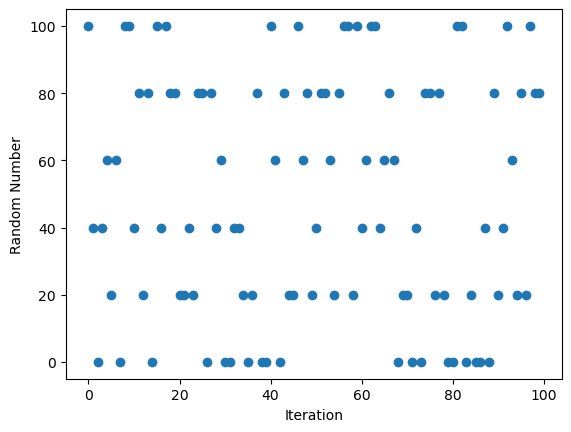

In [7]:
from random import randrange

results = np.empty(N)

for i in range(N):
    results[i] = randrange(0, 101, 20) #random multiples of 20 between [0,100]

plt.figure()
plt.plot(results,"o")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
#plt.show()

Lastly, to choose a random element from a list, use the `choice()` function.

In [8]:
from random import choice

l = ['dog', 'cat', 'horse', 'bird']

choice(l)

'bird'

## Biased coins

We often encounter situations in physics where we want to make some event occur randomly with probability $p$.  To do so, we simply draw a random number according to a uniform probability density in [0,1), and make the event happen if this value is less than $p$.  A classic example is radioactive decay.  

Decay of thallium 208 to lead 208 occurs with a half life $\tau = 3.053$ minutes. We can simulate the number of thallium atoms remaining as a function of time using random numbers, capturing the random nature of radioactive decay.  The number of thallium atoms remaining $N(t)$ after some time interval $t$ is given by $$N(t) = N(0)2^{-t/\tau}.$$  The fraction of thallium atoms remaining is therefore $N(t)/N(0) = 2^{-t/\tau}.$  The fraction which have decayed, which is also the probability $p(t)$ that a particular atom has decayed, is given by $$p(t) = 1-2^{-t/\tau}\tag{2}.$$

To simulate the decay of a collection of thallium atoms, we can  divide time into short intervals and independently apply Equation 2 to each atom in the ensemble to determine if it decays during each time step.

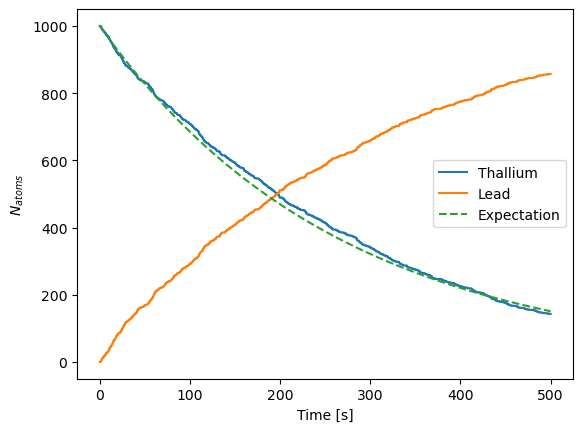

In [9]:
import numpy as np

N = 10000            # Number of time steps to perform
n0Tl = 1000          # Initial number of thallium atoms
n0Pb = 0             # Initial number of lead atoms
tau = 3.053*60       # Half life of thallium in seconds
tMax = 500           # Total time interval

h = tMax/N           # Size of time-step in seconds
p = 1 - 2**(-h/tau)  # Probability of decay in a given time step

seed(8675309)

# Lists of plot points
tValues = np.arange(0,tMax,h)
nTlValues = []
nPbValues = []

# Main loop
nTl = n0Tl
nPb = n0Pb
for t in tValues:
    nTlValues.append(nTl)
    nPbValues.append(nPb)

    # Calculate the number of atoms that decay
    decay = 0
    for i in range(nTl):
        if random()<p: # Check if atom decays during this interval
            decay += 1
    nTl -= decay
    nPb += decay

# Make the graph
plt.figure()
plt.plot(tValues,nTlValues,label="Thallium")
plt.plot(tValues,nPbValues,label="Lead")
plt.plot(tValues,n0Tl*2**(-tValues/tau),linestyle="dashed",label="Expectation")
plt.xlabel("Time [s]")
plt.ylabel("$N_{atoms}$")
plt.legend(loc="best")
#plt.show()

Our modeling of the thallium atoms matches the general expectation for exponential decay, while capturing the statistical fluctuations present in an actual physical system.

### Exercise

The isotope $^{213}$Bi decays to stable $^{209}$Bi via one of two different routes, with probabilities and half-lives as shown in the figure. (Technically, $^{209}$Bi isn't really stable, but it has a half-life of more than $10^{19}$ years, a billion times the age of the universe, so it might as well be.)

<center>
<div>
    <img src="https://raw.githubusercontent.com/jstupak/ComputationalPhysics/master/Images/bismuthDecay.png" width="150"/>
</div>
</center>

Starting with a sample consisting of 10,000 atoms of $^{213}$Bi, simulate the decay of the atoms (as above) by dividing time into slices of length $\delta t = 1$ s each.  On each step doing the following:
1) For each atom of $^{209}$Pb in turn, decide at random, with the appropriate probability, whether it decays or not (the probability can be calculated from Equation 2). Count the total number that decay, subtract it from the number of $^{209}$Pb atoms, and add it to the number of $^{209}$Bi atoms.
2) Now do the same for $^{209}$Tl, except that decaying atoms are subtracted from the total for $^{209}$Tl and added to the total for $^{209}$Pb.
3) For $^{213}$Bi the situation is more complicated: when a $^{213}$Bi atom decays you have to decide at random with the appropriate probability the route by which it decays. Count the numbers that decay by each route and add and subtract accordingly.

Note that you have to work up the chain from the bottom like this, not down from the top, to avoid inadvertently making the same atom decay twice on a single step. 

Keep track of the number of atoms of each of the four isotopes at all times for 20,000 seconds and make a single graph showing the four populations as a function of time on the same axes.

<details>
    <summary style="display:list-item">Click for solution</summary>

```python
import numpy as np

N = 10000            # Number of time steps to perform

n0_213Bi = 10000          # Initial number of 213Bi atoms
n0_209Tl = 0             # Initial number of 209Tl atoms
n0_209Pb = 0             # Initial number of 209Pb atoms
n0_209Bi = 0             # Initial number of 209Pb atoms

tau_213Bi = 46*60       # Half life of 213Bi in seconds
tau_209Tl = 2.2*60      # Half life of 209Tl in seconds
tau_209Pb = 3.3*60      # Half life of 209Pb in seconds

tMax = N           # Total time interval
h = tMax/N           # Size of time-step in seconds

p_213Bi = 1 - 2**(-h/tau_213Bi)  # Probability of 213Bi decay in a given time step
p_209Tl = 1 - 2**(-h/tau_209Tl)  # Probability of 209Tl decay in a given time step
p_209Pb = 1 - 2**(-h/tau_209Pb)  # Probability of 209Pb decay in a given time step

seed(8675309)

# Lists of plot points
tValues = np.arange(0,tMax,h)
n_213BiValues = []
n_209TlValues = []
n_209PbValues = []
n_209BiValues = []

# Main loop
n_213Bi = n0_213Bi
n_209Tl = n0_209Tl
n_209Pb = n0_209Pb
n_209Bi = n0_209Bi
for t in tValues:
    n_213BiValues.append(n_213Bi)
    n_209TlValues.append(n_209Tl)
    n_209PbValues.append(n_209Pb)
    n_209BiValues.append(n_209Bi)

    # Calculate the number of 209Pb atoms that decay
    decay = 0
    for i in range(n_209Pb):
        if random()<p_209Pb: # Check if atom decays during this interval
            decay += 1
    n_209Pb -= decay
    n_209Bi += decay

    # Calculate the number of 209Tl atoms that decay
    decay = 0
    for i in range(n_209Tl):
        if random()<p_209Tl: # Check if atom decays during this interval
            decay += 1
    n_209Tl -= decay
    n_209Pb += decay

    # Calculate the number of 213Bi atoms that decay
    decay = 0
    for i in range(n_213Bi):
        if random()<p_213Bi: # Check if atom decays during this interval
            decay += 1
    n_213Bi -= decay
    # Decide which decay mode to take
    if random()<.9791: n_209Pb += decay
    else: n_209Tl += decay

# Make the graph
plt.figure()
plt.plot(tValues,n_213BiValues,label="$^{213}$Bi")
plt.plot(tValues,n_209TlValues,label="$^{209}$Tl")
plt.plot(tValues,n_209PbValues,label="$^{209}$Pb")
plt.plot(tValues,n_209BiValues,label="$^{209}$Bi")

plt.xlabel("Time [s]")
plt.ylabel("$N_{atoms}$")
plt.yscale('log')
plt.legend(loc="best")
#plt.show()
```
</details>

## Monte Carlo Integration

Surprisingly, we can also use random numbers to perform integration.  As an exmaple, let's integrate $f(x)=\sin(x)$ from $x=0$ to $x=\pi$.

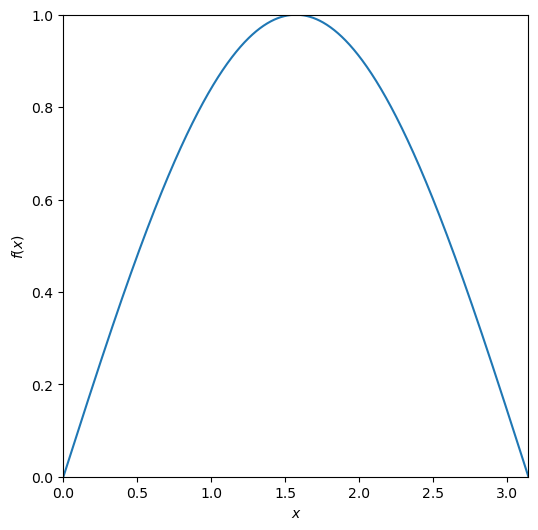

In [10]:
import numpy as np
from math import pi

def f(x):
    return np.sin(x)

xValues = np.linspace(0, pi, 1000)
yValues = f(xValues)

plt.figure(figsize=(6,6))
ax = plt.gca()
ax.set_xlim([0, pi])
ax.set_ylim([0, 1])
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.plot(xValues,yValues)

By definition, the integral $I$ that we seek is the area under the curve.  The total area of the figure above is $A=\pi\times1=\pi$.  If we randomly generate many points in this rectangle, the fraction which lie below the curve should be $f=I/A$.  In other words, $I=fA$.  Let's test this.

In [11]:
N = 100000

count = 0
for i in range(N):
    x = pi*random() #generate random x value
    y = random()   #generate random y value
    if y<f(x):
        count += 1
        
I = (count/N) * pi

I

1.9995608921568317

Given the finite statistics used, we only expect this method to give the approximate value of the integral.  However, comparing with the value of the true integral (2), we see very good agreement.  Of course, unless we fix the seed, we will get a slightly different result each time we perform this calculation (due to statistical fluctuations).

### Exercise
In this exercise, you will calculate the value of $\pi$ using a Monte Carlo technique.  

A circle of radius $R=1$ has area $\pi R^2=\pi$.  Such a circle can be bound within a $2\times2$ square.

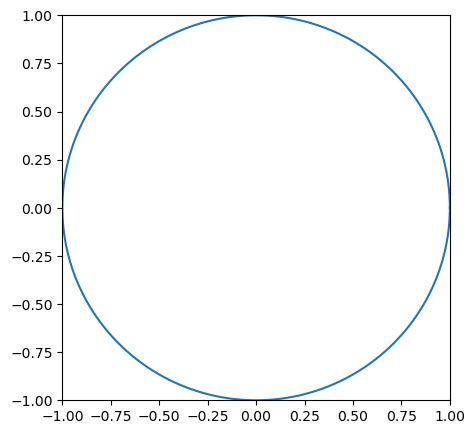

In [12]:
thetaValues = np.linspace(0, 2*np.pi, 1000)
xValues = np.cos(thetaValues)
yValues = np.sin(thetaValues)

plt.figure(figsize=(5, 5))
ax = plt.gca()
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
plt.plot(xValues,yValues)

Generate a series of random numbers within this square, calculate the fraction that fall within the circle, and determine the area of the circle (which, in this particular case, is equal to $\pi$).

<details>
    <summary style="display:list-item">Click for solution</summary>

```python
N = 1000000

count = 0
for i in range(N):
    x = uniform(-1,1) #generate random x value
    y = uniform(-1,1) #generate random y value
    if x**2 + y**2<1:
        count += 1
        
pi = (count/N) * 4

pi
```
</details>

### Mean value method

It turns out that there are more accurate Monte Carlo methods for the calculation of integrals.  One such method makes use of the mean value theorem, which states that the average value of a function $f(x)$ between $x=a$ and $x=b$ is given by $\left<f(x)\right> = \frac{1}{b-a}\int_a^bf(x)\mathrm{d}x.$  Therefore, we can calculate the integral over this range as $\int_a^b f(x)\mathrm{d}x = \left<f(x)\right>(b-a)$.

Thus, we simply need to calculate the average value of $f(x)$ over the domain of integration.  We can do this by generating $N$ random values $x_i$ in this range, summing the values $f(x_i)$, and dividing by the total number of generated values.  In other words, $$\int_a^b f(x)\mathrm{d}x = \frac{\sum_{i=1}^N f(x_i)}{N}(b-a)\tag{3}.$$

Returning to the integral of $f(x) = \sin(x)$ from $x=0$ to $x=\pi$, we can use Equation 3 to calculate the integral via:

In [13]:
N = 10000

sum = 0
for i in range(N):
    x = pi*random() #generate random x value
    y = f(x)
    sum += y
        
I = (sum/N) * pi

I

np.float64(1.9861677280093133)

The error on this Monte Carlo integration method is proportional to $N^{-1/2}$.  The error on the trapezoidal method is instead proportional to $N^{-2}$, which means we can use far fewer sample points with the trapezoidal method to obtain similar error to that of the Monte Carlo method.  Therefore, we should only use Monte Carlo methods when standard numerical techniques fail.  This occurs, for example, when dealing with high-dimension integrals.  To perform an integral in $n_{\mathrm{dim}}$-dimensions with just 100 sample points in each dimension, requires $100^{n_{\mathrm{dim}}}$ total sample points, which becomes unmanagable even for modest values of $n$.  With far fewer points, we can accurately calculate the integral using Monte Carlo methods.

In higher dimensions, the integral of a function $f(\vec{r})$ over an $n$-dimensional volume $V$, is given by a generalization of Equation 3: $$\int f(\vec{r})\mathrm{d}V = \frac{\sum_{i=1}^N f(\vec{r}_i)}{N}V\tag{4}.$$

### Exercise

In this exercise, you will calculate the volume of a 10-dimensional sphrere (of radius $R=1$) using the mean value method.  

First, consider the equivalent problem in 2-dimensions.  We could calculate the area of the circle above by evaluating $I=\int_{-1}^{1}\int_{-1}^{1}f(x,y)~\mathrm{d}x~\mathrm{d}y$ where $f(x,y)=1$ everywhere inside the circle, and $f(x,y)=0$ everywhere outside the circle: $$f(x,y)=
\begin{cases}
    1 & \mathrm{if}~x^2+y^2\leq1\\
    0 & \mathrm{otherwise} \tag{5}.
\end{cases}$$

Application of the mean value method to this integral involves:
1) Generation of $N$ random points with $x,y\in[-1,1)$.
2) Evaluation of Equation 4, with $V=2^{n_{\mathrm{dim}}}$.

Your task is to extend this method to a 10-dimensional sphere using Equation 3 (with appropriate modification of Equation 4).

In [14]:
from math import sqrt

N = 10000000
nDim = 10

def f(r):
    mag2 = 0
    for v in r: mag2 += v**2
    mag = sqrt(mag2)

    if mag<1: return 1
    else:     return 0

sum = 0
for i in range(N):
    r = [random() for i in range(nDim)] #generate random x value
    sum += f(r)
        
I = 2**nDim * (sum/N)

I

2.5357312

<details>
    <summary style="display:list-item">Click for solution</summary>

```
from math import sqrt

N = 100000
nDim = 10

def f(r):
    mag2 = 0
    for v in r: mag2 += v**2
    mag = sqrt(mag2)

    if mag<1: return 1
    else:     return 0

sum = 0
for i in range(N):
    r = [random() for i in range(nDim)] #generate random x value
    sum += f(r)
        
I = 2**nDim * (sum/N)

I
```
</details>

The true volume of a 10-dimensional sphere is 2.55, which is compatible with our calculation.

### Exercise

In this exercise, we will model Brownian motion as a random walk.  

Some background from https://prancer.physics.louisville.edu/modules/random_walks/index.html:

> In 1827, the Scottish botanist Robert Brown looked through his microscope at pollen grains suspended in water and noted that they jittered around in a way he couldn’t explain.
>
> It took until 1905 until a satisfactory answer was provided by Albert Einstein who brought some statistical methods to the problem, predicting that the random motion of the pollen grains was due to water being made up of molecules, which were continually bumping into the pollen grains. First he derived a diffusion equation for the grains, then he showed how to link this to physically measurable quantities starting with the mean squared dispacement (MSD), which we’ll come back to.

Let's see if we can understand the motion of the pollen molecules using a simple model.  To simplify, let's consider the one-dimensional motion of a single pollen grain.

We will assume that during a given (short) time interval, a single water molecule will collide with the pollen grain, pushing it one unit of length to the left or to the right (with equal probability).  To simulate an extended period of time, we simply simulate many such collisions.  This is an example of what we call a "random walk" in physics.  

To study diffusion, we assume that we initially have many such pollen molecules concentrated at $x=0$, and we observe the position of these pollen molecules over time.  Though this model is very simplistic, it turns out to be quite interesting.  

Begin by assuming we have 1,000 pollen grains.  Simulate the motion of each pollen grain for 10 units of time.  During each unit of time, each pollen grain should randomly "step" 1 unit of length to the left or right.  Plot the displacement of each pollen grain as a function of time.  Hint: I would create a 2-dimensional array to store the random steps (each row corresponding to a pollen grain, each column to a time step).

Text(0, 0.5, 'Displacement')

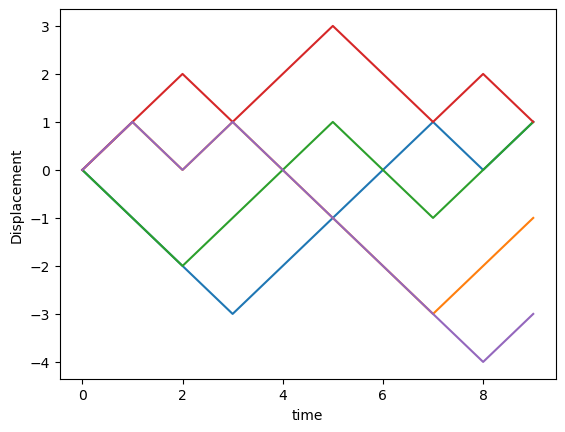

In [25]:
nWalkers = 5    # Number of walkers
nSteps   = 10   # Number of steps

#Simulate the random walk of each pollen grain
def randomWalk(nWalkers, nSteps):

    steps = np.random.choice([1,-1],size=(nWalkers,nSteps)) #2D array with a row for each walker, column for each step

    return steps

#Sum each individual step to determine cumulative position as a function of time
def getCumulativePos(steps):
    result = np.zeros(steps.shape)

    for row in range(steps.shape[0]):
        for column in range(1,steps.shape[1]):
            result[row,column] = np.sum(steps[row][:column])
    
    return result
    
steps = randomWalk(nWalkers, nSteps)
cumulativePos = getCumulativePos(steps)

plt.figure()
plt.plot(cumulativePos.T)  #each column is treated as a data series - transpose to plot each pollen grain as a function of time
plt.xlabel('Time')
plt.ylabel('Displacement')

As a function of time, calculate the mean displacement of all pollen grains.

In [19]:
def getMean(arr):
    result = np.zeros(arr.shape[1])

    for column in range(arr.shape[1]):
        result[column] = np.mean(arr[:,column])
    
    return result

steps = randomWalk(nWalkers, nSteps)
cumulativePos = getCumulativePos(steps)
cumulativePosMean = getMean(cumulativePos)

cumulativePosMean

array([ 0. , -0.2, -0.4, -0.6, -0.4, -0.6, -0.8, -1.4, -1.6, -1. ])

Plot the mean displacement as a function of time for three cases:
1) 10 pollen grains
3) 1,000 pollen grains
4) 100,000 pollen grains

Text(0, 0.5, 'mean displacement')

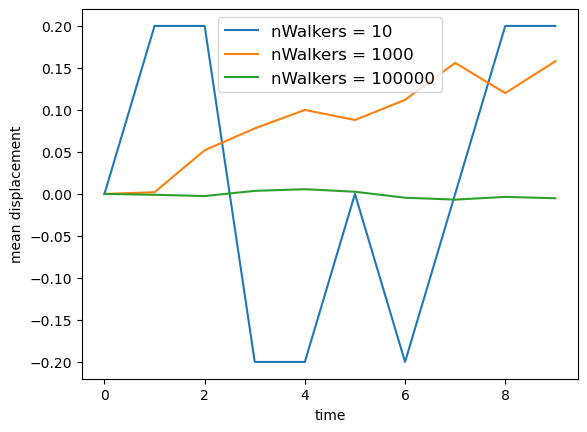

In [20]:
plt.figure()

for nWalkers in [10, 1000, 100000]:
    steps = randomWalk(nWalkers, nSteps)
    cumulativePos = getCumulativePos(steps)
    plt.plot(getMean(cumulativePos),label='nWalkers = %i'%nWalkers)

plt.legend(loc='best', fontsize='large')
plt.xlabel('time')
plt.ylabel('mean displacement')

Since the probability for a particular pollen grain to move left or right during a particular time step is equal, on average we expect the displacement of all pollen grains to be zero.  Any deviation from 0 is indicative of statistical fluctuations.  What can you say about the dependence of the size of statistical fluctuations on the number of pollen grains considered?

Make a histogram of the final displacement of 1,000 pollen grains.

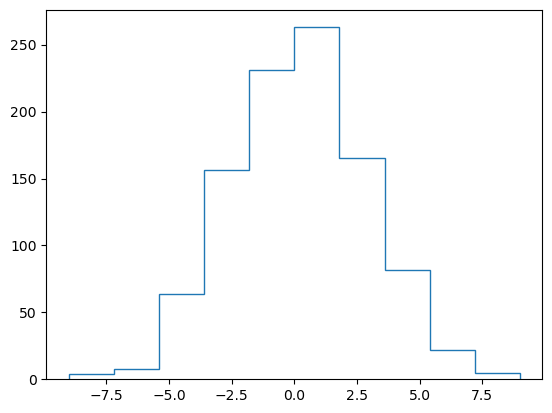

In [21]:
nWalkers = 1000

steps = randomWalk(nWalkers, nSteps)
cumulativePos = getCumulativePos(steps)
finalPositions = cumulativePos[:,-1]

plt.figure()
(n,binEdges,patches) = plt.hist(finalPositions, histtype='step')

Empirically, we observe this distribution to be Gaussian.  Is our simple model compatible with this observation?

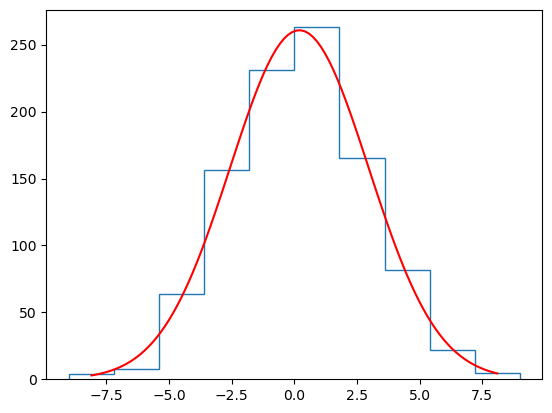

In [22]:
from scipy.optimize import curve_fit

plt.figure()
(n,binEdges,patches) = plt.hist(finalPositions, histtype='step')

def gaussian(x, amplitude, mean, stdDev):
        return amplitude * np.exp(-((x - mean) / stdDev)**2 / 2)

binCenters = 0.5*(binEdges[:-1] + binEdges[1:])   #get the bin centers
popt, pcov = curve_fit(gaussian, binCenters, n, p0 = [nWalkers, 0, sqrt(nWalkers)])
amplitude, mean, stdDev = popt

denseXValues=np.linspace(binCenters[0], binCenters[-1], 100)
plt.plot(denseXValues, gaussian(denseXValues, amplitude, mean, stdDev), 'r')

Plot the mean *squared* displacement of 1,000 pollen grains as a function of time.

Text(0, 0.5, 'mean squared displacement')

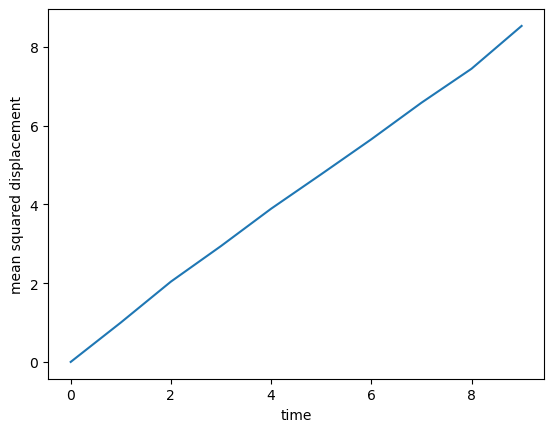

In [23]:
nWalkers = 1000

def getCumulativePos2(steps):
    return pow(getCumulativePos(steps),2)

steps = randomWalk(nWalkers, nSteps)
cumulativePos2 = getCumulativePos2(steps)

plt.plot(getMean(cumulativePos2))
plt.xlabel('time')
plt.ylabel('mean squared displacement')

Empirically, we observe that the mean squared displacement is equal to $2dDt$, where $d$ is the number of dimensions, $D$ is the diffusion coefficient, and $t$ is time.  Is our simple model compatible with this observation?

 What is the diffusion coefficient?

In [24]:
from scipy.optimize import curve_fit

def linear(x, m, b):
    return m*x + b

popt, pcov = curve_fit(linear, getMean(cumulativePos2), range(nSteps), p0 = [1, 0])
D = popt[0]/2

D

np.float64(0.5364911617133827)